In [25]:
pd.read_csv('train_filtered_last3.csv')

,Date,Store,Dept,Weekly_Sales,IsHoliday,Type,Size
0,2010-02-07,22.141477,43.599724,14839.443768,0.0,1.595583,136554.544513
1,2010-02-14,22.103838,43.966073,15123.649805,1.0,1.588759,137219.516450
2,2010-02-21,22.136240,43.894755,14910.519946,0.0,1.592643,136727.899183
3,2010-02-28,22.100996,43.733425,13796.492360,0.0,1.591893,136887.003092
4,2010-03-07,22.155916,43.615730,14481.592447,0.0,1.591583,136959.692998
...,...,...,...,...,...,...,...
138,2012-09-30,22.265438,43.776527,13963.669342,0.0,1.599113,135657.443193
139,2012-10-07,22.289411,44.093292,14808.582315,0.0,1.596527,135948.866871
140,2012-10-14,22.245685,44.207445,14454.127195,0.0,1.597970,135800.083587
141,2012-10-21,22.292850,43.794047,14309.931717,0.0,1.604174,135487.223401


In [29]:
model.nobs

100

In [35]:
model = joblib.load('SARIMAX_model.pkl')
model.nobs

100

Full data shape: (143, 7)

Evaluation Metrics:
Mean Squared Error (MSE): 433461.04
Mean Absolute Error (MAE): 517.47

Sorted Feature Importance (by absolute coefficient):
Empty DataFrame
Columns: [Feature, Coefficient]
Index: []


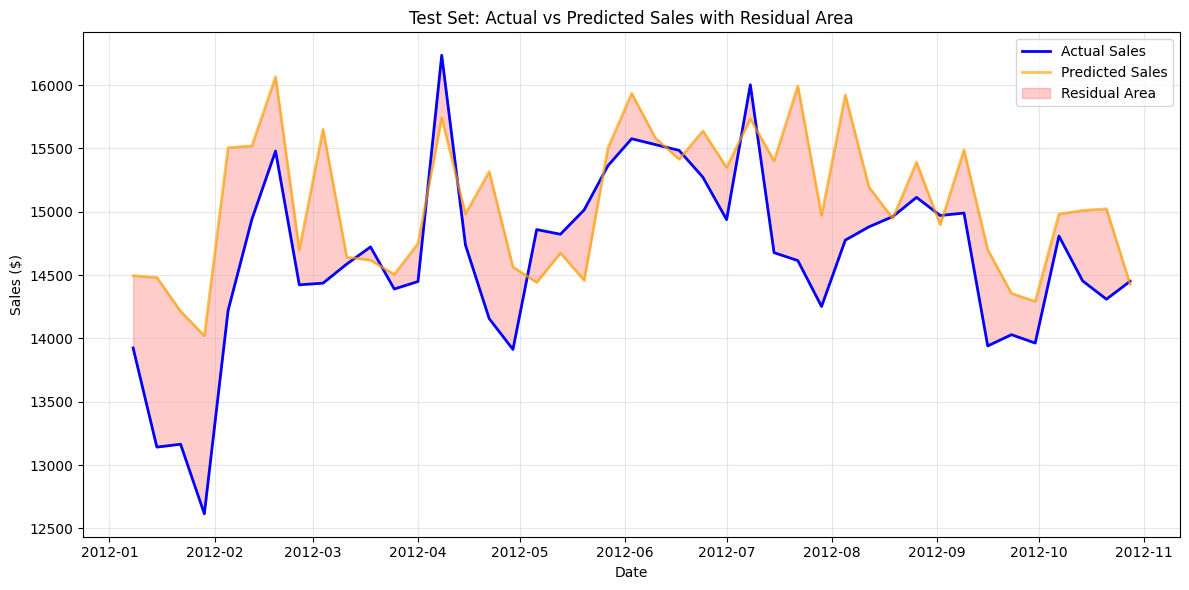

In [54]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

def main():
    # Load model trained on first 100 samples
    model = joblib.load('SARIMAX_model.pkl')

    # Load full dataset
    df = pd.read_csv('train_filtered_last3.csv')
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').reset_index(drop=True)

    print("Full data shape:", df.shape)

    # Split into test (next 43 weeks)
    test_df = df.iloc[100:143]
    exog_test = test_df[['Store', 'Dept', 'IsHoliday', 'Type', 'Size']]

    # Forecast next 43 weeks
    forecast_result = model.get_forecast(steps=43, exog=exog_test)
    forecast_df = forecast_result.summary_frame()
    forecast_df['Date'] = test_df['Date'].values
    forecast_df['Actual Sales'] = test_df['Weekly_Sales'].values
    forecast_df = forecast_df.rename(columns={'mean': 'Predicted Sales'})

    # Compute absolute percentage error per point
    forecast_df['APE'] = np.abs((forecast_df['Actual Sales'] - forecast_df['Predicted Sales']) / forecast_df['Actual Sales']) * 100

    # Normalize APE to control alpha (inverted: lower error = higher alpha)
    max_error = forecast_df['APE'].max()
    forecast_df['Alpha'] = 1 - (forecast_df['APE'] / max_error)  # Alpha ∈ [0,1]

    # --- MSE and MAE ---
    mse = mean_squared_error(forecast_df['Actual Sales'], forecast_df['Predicted Sales'])
    mae = mean_absolute_error(forecast_df['Actual Sales'], forecast_df['Predicted Sales'])

    print(f"\nEvaluation Metrics:")
    print(f"Mean Squared Error (MSE): {mse:.2f}")
    print(f"Mean Absolute Error (MAE): {mae:.2f}")

    # --- Feature Importance from SARIMAX Coefficients ---
    exog_coefs = model.params.filter(like='exog.')
    importance_df = pd.DataFrame({
        'Feature': exog_coefs.index.str.replace('exog.', '', regex=False),
        'Coefficient': exog_coefs.values,
        'Abs_Coefficient': np.abs(exog_coefs.values)
    }).sort_values('Abs_Coefficient', ascending=False)

    print("\nSorted Feature Importance (by absolute coefficient):")
    print(importance_df[['Feature', 'Coefficient']])

    # --- Plot ---
    plt.figure(figsize=(12, 6))

    # Plot actual sales
    plt.plot(forecast_df['Date'], forecast_df['Actual Sales'], label='Actual Sales', color='blue', linewidth=2)

    # Plot predicted sales with mean alpha
    mean_alpha = forecast_df['Alpha'].mean()
    plt.plot(forecast_df['Date'], forecast_df['Predicted Sales'], label='Predicted Sales', color='orange', linewidth=2, alpha=mean_alpha)

    # Fill the area between actual and predicted sales
    plt.fill_between(
        forecast_df['Date'],
        forecast_df['Actual Sales'],
        forecast_df['Predicted Sales'],
        color='red',
        alpha=0.2,
        label='Residual Area'
    )

    plt.title('Test Set: Actual vs Predicted Sales with Residual Area')
    plt.xlabel('Date')
    plt.ylabel('Sales ($)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
   

if __name__ == "__main__":
    main()


In [52]:
# Try to extract all non-intercept parameters
exog_coefs = model.params[~model.params.index.str.contains('sigma2|intercept|ar.|ma.|sar.|seasonal')]

# Show sorted coefficients (assuming these are exogenous)
importance_df = pd.DataFrame({
    'Feature': exog_coefs.index,
    'Coefficient': exog_coefs.values,
    'Abs_Coefficient': np.abs(exog_coefs.values)
}).sort_values('Abs_Coefficient', ascending=False)

print("\nSorted Feature Importance (by absolute coefficient):")
print(importance_df[['Feature', 'Coefficient']])



Sorted Feature Importance (by absolute coefficient):
     Feature   Coefficient
3       Type  32183.830076
1       Dept   2287.694702
0      Store    303.268543
2  IsHoliday    232.835878
4       Size     -1.063636
